In [66]:
from __future__ import annotations
from typing import Dict,List,TypedDict,Optional
import time
from langgraph.graph import StateGraph,END
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore



In [67]:
embeddings=OpenAIEmbeddings()
llm="gpt-4o-mini"
llm_temp=0
Retrieve_top_k=4
Cache_top_k=3
Cache_Distance_Threshold=0.45
Cache_TTL_secs=0


In [68]:
class RAGState(TypedDict):
    question:str
    normalized_question:str
    context_docs:List[Document]
    answer:str
    citations:List[str]
    cache_hits:bool


In [69]:
embeddings=OpenAIEmbeddings()
VECTOR_DIM=1536


In [70]:
### QA Chache

qa_index=faiss.IndexFlatL2(VECTOR_DIM)  ###Distance:Lower is better
QA_Chache=FAISS(embedding_function=embeddings,index=qa_index,docstore=InMemoryDocstore({}),index_to_docstore_id={})

In [71]:
QA_Chache

In [72]:
RAG_Store=FAISS.from_texts(
    texts=["Langgraph is a framework for building applications that can use llms and other tools to perform complex tasks.It allows developers to create applicatiions that can reason,plan and execute tasks using llms and other tools.",
    "in langgraph you can create a state graph that defines the flow of your application and how it interacts with llms and other tools.",
    "Retrieval Augmented Generation is a technique that combines the power of llms with external knowledge sources to generate more accurate and relevant responds.",
    "Semantic catching reuses the power of embeddings to store and retrieve relevant information based on the semantic meaning of the content rather than just keywords."],
    embedding=embeddings,
)

In [33]:
LLM=ChatOpenAI(model_name=llm,temperature=llm_temp)


In [73]:
### Normalize Questiion
def normalize_question(state:RAGState)->RAGState:
    """
    Normalize the question by converting it to lowercase and stripping whitespace.
    """
    state['normalized_question'] = state['question'].lower().strip()
    return state

In [74]:
### Semantic Caching
def semantic_cache_lookup(state:RAGState)->RAGState:
    """
    Perform a semantic cache lookup for the normalized question.
    If a relevant cached answer is found, populate the state with the cached answer and citations.
    """
    # Perform a similarity search in the QA cache
    results = QA_Chache.similarity_search(state['normalized_question'], k=Cache_top_k)
    
    # Check if any results are found
    if results:
        # Assuming the first result is the most relevant
        cached_doc = results[0]
        state['answer'] = cached_doc.page_content
        state['citations'] = [cached_doc.metadata.get('source', 'Unknown Source')]
        state['cache_hits'] = True
    else:
        state['cache_hits'] = False
    
    return state



In [76]:
### Respond from Cache
def respond_from_cache(state:RAGState)->RAGState:
    """
    If a cached answer is available, return it as the final answer.
    """
    if state['cache_hits']:
        print("Responding from cache.")
        return state
    else:
        print("No cached response found.")
        return state

In [77]:
### Retrieval Docs
def retrieve_docs(state:RAGState)->RAGState:
    """
    Retrieve relevant documents from the RAG store based on the normalized question.
    """
    results = RAG_Store.similarity_search(state['normalized_question'], k=Retrieve_top_k)
    state['context_docs'] = results
    return state

In [78]:
### Generate Answer
def generate_answer(state:RAGState)->RAGState:
    """
    Generate an answer using the LLM based on the normalized question and retrieved context documents.
    """
    # Combine the context documents into a single string
    context_text = "\n".join([doc.page_content for doc in state['context_docs']])
    
    # Create a prompt for the LLM
    prompt = f"Question: {state['normalized_question']}\nContext: {context_text}\nAnswer:"
    
    # Generate the answer using the current LangChain Runnable API
    response = LLM.invoke(prompt)
    
    # Store the generated answer and citations in the state
    state['answer'] = response.content
    state['citations'] = [doc.metadata.get('source', 'Unknown Source') for doc in state['context_docs']]
    
    return state

In [79]:
### Cache Write
def cache_write(state:RAGState)->RAGState:
    """
    Write the generated answer to the QA cache for future retrieval.
    """
    if not state['cache_hits']:
        # Create a new Document for the answer
        answer_doc = Document(
            page_content=state['answer'],
            metadata={'source': 'Generated Answer'}
        )
        
        # Add the answer document to the QA cache
        QA_Chache.add_documents([answer_doc])
    
    return state

In [80]:
### Graph Construction
def construct_rag_graph():
    """Construct and compile the RAG state graph."""
    graph = StateGraph(RAGState)

    graph.add_node('normalize_question', normalize_question)
    graph.add_node('semantic_cache_lookup', semantic_cache_lookup)
    graph.add_node('respond_from_cache', respond_from_cache)
    graph.add_node('retrieve_docs', retrieve_docs)
    graph.add_node('generate_answer', generate_answer)
    graph.add_node('cache_write', cache_write)

    graph.set_entry_point('normalize_question')
    graph.add_edge('normalize_question', 'semantic_cache_lookup')
    graph.add_edge('semantic_cache_lookup', 'respond_from_cache')
    graph.add_conditional_edges(
        'respond_from_cache',
        lambda state: 'retrieve_docs' if not state['cache_hits'] else END,
        {'retrieve_docs': 'retrieve_docs', END: END},
    )
    graph.add_edge('retrieve_docs', 'generate_answer')
    graph.add_edge('generate_answer', 'cache_write')
    graph.add_edge('cache_write', END)

    return graph.compile(checkpointer=MemorySaver())


app = construct_rag_graph()


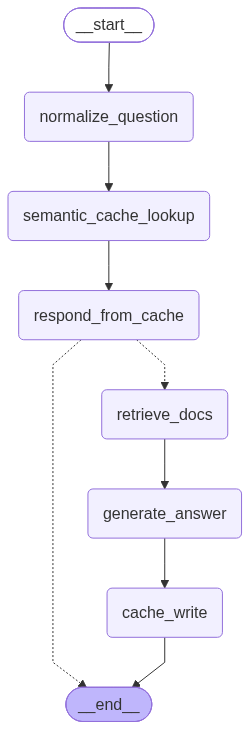

In [84]:
app

In [81]:
thread_cfg = {'configurable': {'thread_id': 'demo_user_1'}}
q1 = 'What is LangGraph?'
output = app.invoke({'question': q1}, config=thread_cfg)
print('Final Answer:', output['answer'])
print('Citations:', output['citations'])
print('Cache Hits:', output['cache_hits'])


No cached response found.
Final Answer: Langgraph is a framework designed for building applications that leverage large language models (LLMs) and various tools to perform complex tasks. It enables developers to create applications capable of reasoning, planning, and executing tasks by defining a state graph that outlines the flow of the application and its interactions with LLMs and other tools. Key features of Langgraph include Retrieval Augmented Generation, which enhances the accuracy and relevance of responses by integrating external knowledge sources, and Semantic Caching, which utilizes embeddings to store and retrieve information based on the semantic meaning of content rather than relying solely on keywords.
Citations: ['Unknown Source', 'Unknown Source', 'Unknown Source', 'Unknown Source']
Cache Hits: False


In [83]:
thread_cfg = {'configurable': {'thread_id': 'demo_user_1'}}
q1 = 'Explain about LangGraph?'
output = app.invoke({'question': q1}, config=thread_cfg)
print('Final Answer:', output['answer'])
print('Citations:', output['citations'])
print('Cache Hits:', output['cache_hits'])


Responding from cache.
Final Answer: Langgraph is a framework designed for building applications that leverage large language models (LLMs) and various tools to perform complex tasks. It enables developers to create applications capable of reasoning, planning, and executing tasks by defining a state graph that outlines the flow of the application and its interactions with LLMs and other tools. Key features of Langgraph include Retrieval Augmented Generation, which enhances the accuracy and relevance of responses by integrating external knowledge sources, and Semantic Caching, which utilizes embeddings to store and retrieve information based on the semantic meaning of content rather than relying solely on keywords.
Citations: ['Generated Answer']
Cache Hits: True
